In [6]:
import warnings

warnings.filterwarnings("ignore")

In [7]:
import scvi
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

In [8]:
EPOCHS = 250
LATENT_DIM = 50

In [9]:
def seurat_like_clustering(adata):
    """
    Simulates Seurat's graph-based clustering using Scanpy (Louvain/Leiden on PCA KNN graph).
    """
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
    adata = adata[:, adata.var.highly_variable]
    sc.pp.scale(adata, max_value=10)
    sc.tl.pca(adata, svd_solver="arpack")

    # Seurat's FindNeighbors equivalent
    sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

    # Compute UMAP for PCA
    sc.tl.umap(adata)
    adata.obsm["X_umap_pca"] = adata.obsm["X_umap"].copy()

    # Seurat's FindClusters equivalent (Louvain or Leiden)
    sc.tl.leiden(adata, resolution=0.8, key_added="seurat_leiden")

    return adata


def seurat_scvi_clustering(adata):
    """
    Modified Seurat workflow that substitutes PCA with scVI latent representations.
    Assumes adata.layers['counts'] contains unnormalized raw counts.
    """
    if scvi is None:
        print("scvi-tools is not installed. Skipping scVI integration.")
        adata.obs["seurat_scvi_leiden"] = "N/A"
        return adata, None

    print("Setting up scVI on 'counts' layer...")
    # Setup scVI, directing it to the unnormalized counts
    scvi.model.SCVI.setup_anndata(adata, layer="counts")

    print("Training scVI model...")
    model = scvi.model.SCVI(adata, n_latent=LATENT_DIM)
    model.train(
        max_epochs=EPOCHS,
        accelerator="mps",
        devices=1,
        train_size=0.9,
        validation_size=0.1,
        check_val_every_n_epoch=1,
    )

    # Extract the latent representation
    adata.obsm["X_scvi"] = model.get_latent_representation()

    # Graph-based clustering using scVI latent embeddings instead of PCA
    print("Running Leiden clustering on scVI latent space...")
    sc.pp.neighbors(adata, use_rep="X_scvi", n_neighbors=10)

    # Compute UMAP for scVI
    sc.tl.umap(adata)
    adata.obsm["X_umap_scvi"] = adata.obsm["X_umap"].copy()

    sc.tl.leiden(adata, resolution=0.8, key_added="seurat_scvi_leiden")

    return adata, model


def seurat_linear_scvi_clustering(adata):
    """
    Modified Seurat workflow that substitutes PCA with LinearSCVI representations.
    LinearSCVI ensures the decoder maps linearly back to gene space, allowing interpretability.
    """
    if scvi is None:
        print("scvi-tools is not installed. Skipping LinearSCVI integration.")
        adata.obs["seurat_linear_scvi_leiden"] = "N/A"
        return adata, None

    print("Setting up LinearSCVI on 'counts' layer...")
    scvi.model.LinearSCVI.setup_anndata(adata, layer="counts")

    print("Training LinearSCVI model...")
    model = scvi.model.LinearSCVI(adata, n_latent=LATENT_DIM)
    model.train(
        max_epochs=EPOCHS,
        accelerator="mps",
        devices=1,
        train_size=0.9,
        validation_size=0.1,
        check_val_every_n_epoch=1,
    )

    adata.obsm["X_linear_scvi"] = model.get_latent_representation()

    print("Running Leiden clustering on LinearSCVI latent space...")
    sc.pp.neighbors(adata, use_rep="X_linear_scvi", n_neighbors=10)

    # Compute UMAP for LinearSCVI
    sc.tl.umap(adata)
    adata.obsm["X_umap_linear_scvi"] = adata.obsm["X_umap"].copy()

    sc.tl.leiden(adata, resolution=0.8, key_added="seurat_linear_scvi_leiden")

    return adata, model

Loading BMMC dataset...
Running Seurat-like graph clustering (PCA)...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Running modified Seurat graph clustering (scVI)...
Setting up scVI on 'counts' layer...
Training scVI model...
Epoch 250/250: 100%|██████████| 250/250 [18:21<00:00,  4.29s/it, v_num=1, train_loss=714]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|██████████| 250/250 [18:21<00:00,  4.41s/it, v_num=1, train_loss=714]
Running Leiden clustering on scVI latent space...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Running modified Seurat graph clustering (LinearSCVI)...
Setting up LinearSCVI on 'counts' layer...
Training LinearSCVI model...
Epoch 250/250: 100%|██████████| 250/250 [09:17<00:00,  2.15s/it, v_num=1, train_loss=790]

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|██████████| 250/250 [09:17<00:00,  2.23s/it, v_num=1, train_loss=790]
Running Leiden clustering on LinearSCVI latent space...
Computing clustering similarity (ARI)...
Adjusted Rand Index between Seurat-like (PCA) and Ground Truth: 0.542
Adjusted Rand Index between Seurat-like (scVI) and Ground Truth: 0.667
Adjusted Rand Index between Seurat-like (LinearSCVI) and Ground Truth: 0.744
Saved combined loss curves to all_loss_curves.png


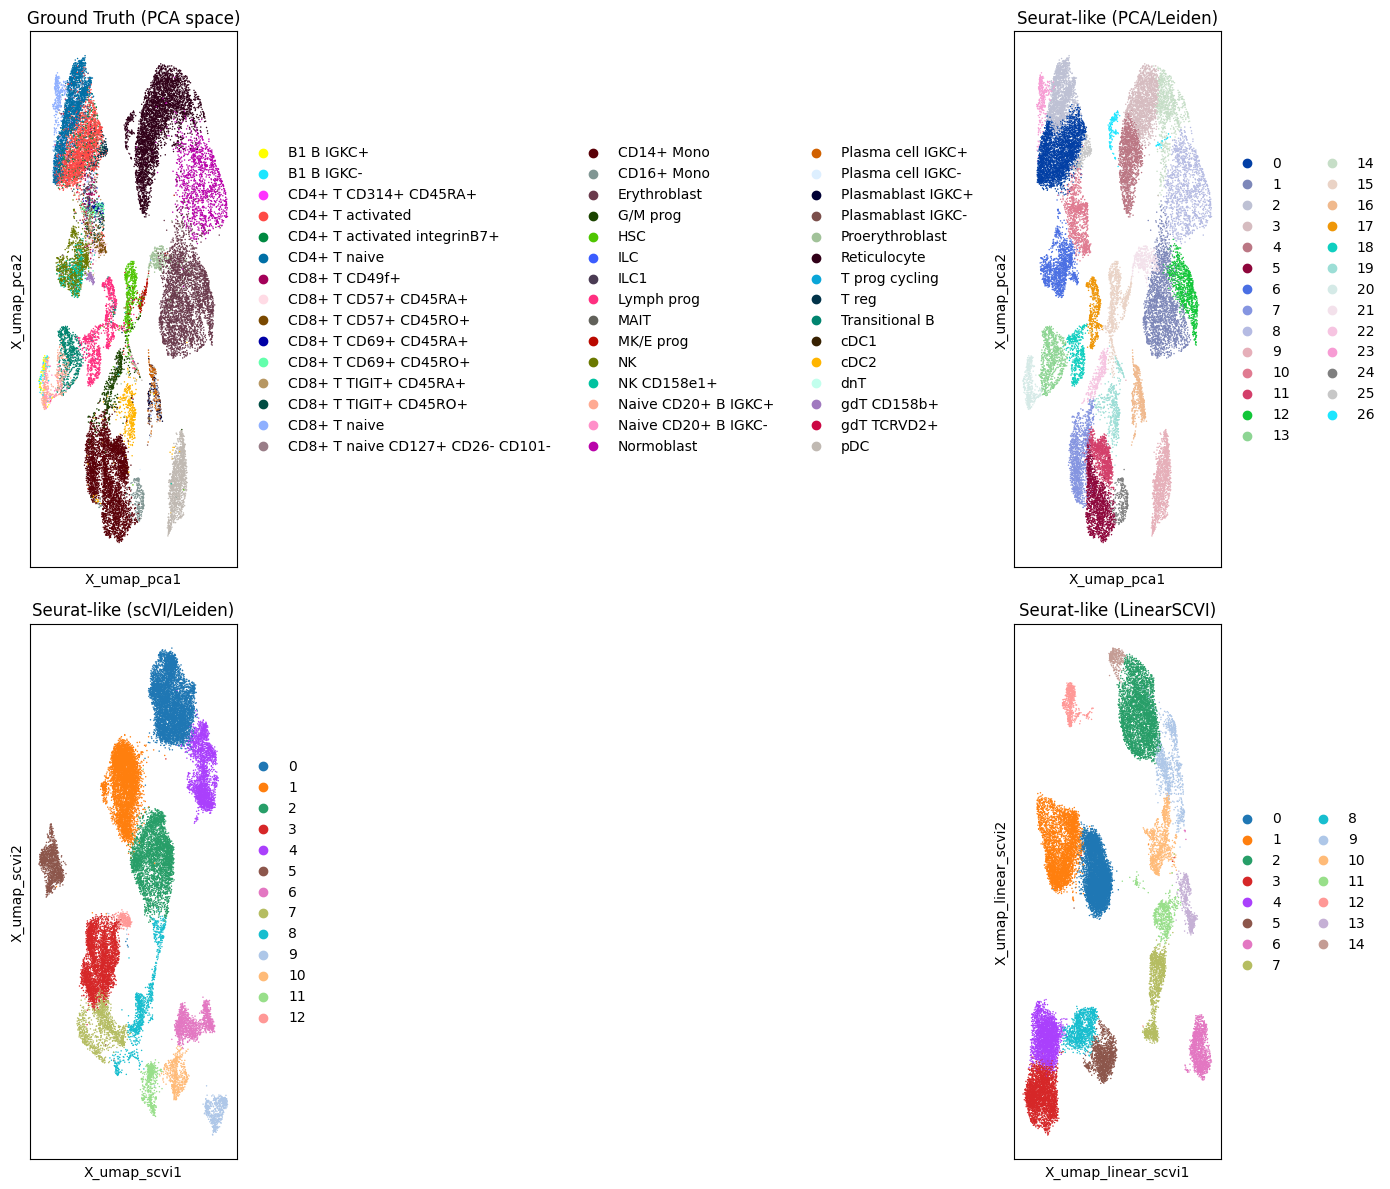

In [10]:
dataset = "bmmc"  # Options: "pbmc", "bbmc", "simulated"

if dataset == "pbmc":
    print("Loading PBMC 3k dataset...")
    adata = sc.datasets.pbmc3k()

    adata_processed = sc.datasets.pbmc3k_processed()
    common_cells = adata.obs_names.intersection(adata_processed.obs_names)
    adata = adata[common_cells].copy()
    adata.obs["ground_truth"] = adata_processed.obs.loc[common_cells, "louvain"]
elif dataset == "bmmc":
    print("Loading BMMC dataset...")
    adata = sc.read_h5ad("data/bmmc.h5ad")
    adata.obs["ground_truth"] = adata.obs[
        "cell_type"
    ]  # Assuming 'leiden' column has the original clusters
else:
    print("Loading simulated dataset...")
    adata = sc.datasets.blobs(
        n_cells=3000, n_genes=2000, centers=5, cluster_std=0.5, random_state=42
    )
    adata.obs["ground_truth"] = adata.obs[
        "leiden"
    ]  # 'leiden' is the default cluster label for blobs

# 2. Basic QC and filtering
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)
adata = adata[adata.obs.pct_counts_mt < 5, :]

# Save raw counts into a layer for scVI because the next step standardizes adata.X
adata.layers["counts"] = adata.X.copy()

# 3. Run Seurat-like clustering (Scanpy)
print("Running Seurat-like graph clustering (PCA)...")
adata = seurat_like_clustering(adata)

# 4. Run modified Seurat clustering (scVI)
print("Running modified Seurat graph clustering (scVI)...")
adata, scvi_model = seurat_scvi_clustering(adata)

# 5. Run modified Seurat clustering (scVI)
print("Running modified Seurat graph clustering (LinearSCVI)...")
adata, linear_scvi_model = seurat_linear_scvi_clustering(adata)

# 6. Compare using ARI (Adjusted Rand Index) against "Ground Truth"
print("Computing clustering similarity (ARI)...")

ari_pca_truth = adjusted_rand_score(
    adata.obs["seurat_leiden"], adata.obs["ground_truth"]
)
print(
    f"Adjusted Rand Index between Seurat-like (PCA) and Ground Truth: {ari_pca_truth:.3f}"
)

if (
    "seurat_scvi_leiden" in adata.obs
    and str(adata.obs["seurat_scvi_leiden"].iloc[0]) != "N/A"
):
    ari_scvi_truth = adjusted_rand_score(
        adata.obs["seurat_scvi_leiden"], adata.obs["ground_truth"]
    )
    print(
        f"Adjusted Rand Index between Seurat-like (scVI) and Ground Truth: {ari_scvi_truth:.3f}"
    )

if (
    "seurat_linear_scvi_leiden" in adata.obs
    and str(adata.obs["seurat_linear_scvi_leiden"].iloc[0]) != "N/A"
):
    ari_linear_scvi_truth = adjusted_rand_score(
        adata.obs["seurat_linear_scvi_leiden"], adata.obs["ground_truth"]
    )
    print(
        f"Adjusted Rand Index between Seurat-like (LinearSCVI) and Ground Truth: {ari_linear_scvi_truth:.3f}"
    )

# Visualization using each method's own UMAP embedding
plot_configs = []

if "X_umap_ground_truth" in adata.obsm:
    plot_configs.append(
        ("X_umap_ground_truth", "ground_truth", "Ground Truth (Original UMAP)")
    )
else:
    plot_configs.append(("X_umap_pca", "ground_truth", "Ground Truth (PCA space)"))

plot_configs.append(("X_umap_pca", "seurat_leiden", "Seurat-like (PCA/Leiden)"))

if (
    "seurat_scvi_leiden" in adata.obs
    and str(adata.obs["seurat_scvi_leiden"].iloc[0]) != "N/A"
):
    plot_configs.append(
        ("X_umap_scvi", "seurat_scvi_leiden", "Seurat-like (scVI/Leiden)")
    )

if (
    "seurat_linear_scvi_leiden" in adata.obs
    and str(adata.obs["seurat_linear_scvi_leiden"].iloc[0]) != "N/A"
):
    plot_configs.append(
        ("X_umap_linear_scvi", "seurat_linear_scvi_leiden", "Seurat-like (LinearSCVI)")
    )

# Plot and save all loss curves in a single figure
loss_models = []
if scvi_model is not None:
    loss_models.append(("scVI", scvi_model))
if linear_scvi_model is not None:
    loss_models.append(("LinearSCVI", linear_scvi_model))

if loss_models:
    num_loss = len(loss_models)
    fig_loss, axes_loss = plt.subplots(1, num_loss, figsize=(6 * num_loss, 5))

    if num_loss == 1:
        axes_loss = [axes_loss]

    for ax, (model_name, model_obj) in zip(axes_loss, loss_models):
        train_elbo = model_obj.history["elbo_train"]
        val_elbo = model_obj.history["elbo_validation"]

        ax.plot(train_elbo.index, train_elbo.values, label="Train Loss (ELBO)")
        ax.plot(val_elbo.index, val_elbo.values, label="Validation Loss (ELBO)")
        ax.set_title(f"{model_name} Training and Validation Loss")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("ELBO Loss")
        ax.legend()

    plt.tight_layout()
    plt.savefig("all_loss_curves.png")
    print("Saved combined loss curves to all_loss_curves.png")
    plt.close(fig_loss)

num_plots = len(plot_configs)

# Calculate grid size (max 3 plots per row)
cols = 2
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))

# Flatten axes if needed
if rows > 1 or cols > 1:
    axes = axes.flatten()
else:
    axes = [axes]

for ax, (basis, color, title) in zip(axes, plot_configs):
    sc.pl.embedding(adata, basis=basis, color=color, title=title, ax=ax, show=False)

# Hide any unused subplots
for i in range(len(plot_configs), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()